In [1]:
import os
import obspy
import numpy as np
from tqdm import tqdm
from obspy.signal.trigger import recursive_sta_lta, trigger_onset

def batch_convert_earthquake_3c(root_dir, output_root):
    total_files = sum([len(files) for r, d, files in os.walk(root_dir) if any(f.endswith('.mseed') for f in files)])
    pbar = tqdm(total=total_files, desc="Auto-Cropping Gempa 3C")

    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.endswith(".mseed"):
                mseed_path = os.path.join(root, file)
                relative_path = os.path.relpath(root, root_dir)
                save_dir = os.path.join(output_root, relative_path)
                os.makedirs(save_dir, exist_ok=True)
                
                try:
                    st = obspy.read(mseed_path)
                    
                    # Pastikan 3 komponen tersedia
                    if len(st.select(component='Z')) == 0 or \
                       len(st.select(component='N')) == 0 or \
                       len(st.select(component='E')) == 0:
                        pbar.update(1)
                        continue
                        
                    tr_z = st.select(component='Z')[0]
                    tr_n = st.select(component='N')[0]
                    tr_e = st.select(component='E')[0]
                    
                    # ==========================================
                    # 1. PRE-PROCESSING KETIGA KOMPONEN
                    # ==========================================
                    traces = [tr_z, tr_n, tr_e]
                    for tr in traces:
                        tr.detrend('demean')
                        tr.detrend('linear')
                        if tr.stats.sampling_rate != 100.0:
                            tr.resample(100.0)
                        tr.filter('bandpass', freqmin=1.0, freqmax=20.0, corners=4, zerophase=True)
                    
                    # ==========================================
                    # 2. TRIGGER STA/LTA (HANYA PADA Z)
                    # ==========================================
                    data_z = tr_z.data
                    data_n = tr_n.data
                    data_e = tr_e.data
                    
                    sta_len = int(0.5 * 100)
                    lta_len = int(3.0 * 100)
                    
                    if len(data_z) < lta_len:
                        pbar.update(1)
                        continue
                        
                    cft = recursive_sta_lta(data_z, sta_len, lta_len)
                    onsets = trigger_onset(cft, 2.5, 0.5)
                    
                    # ==========================================
                    # 3. POTONG Z, N, E DI JENDELA YANG SAMA
                    # ==========================================
                    if len(onsets) > 0:
                        p_arrival_idx = onsets[0][0]
                        start_idx = max(0, p_arrival_idx - 100)
                        end_idx = start_idx + 700
                        
                        # Pastikan semua channel punya data yang cukup di indeks tersebut
                        if end_idx <= min(len(data_z), len(data_n), len(data_e)):
                            win_z = data_z[start_idx:end_idx]
                            win_n = data_n[start_idx:end_idx]
                            win_e = data_e[start_idx:end_idx]
                            
                            # Tumpuk menjadi matriks (3, 700)
                            window_3c = np.array([win_z, win_n, win_e])
                            
                            # Normalisasi Global (Max-Absolute dari seluruh matriks)
                            # Agar rasio amplitudo asli antar komponen (Z/N/E) tetap terjaga
                            max_val = np.max(np.abs(window_3c))
                            if max_val > 0:
                                window_3c = window_3c / max_val
                                
                            window_3c = window_3c.astype(np.float32)
                            
                            file_name = f"{os.path.splitext(file)[0]}_3C_AUTO.npy"
                            np.save(os.path.join(save_dir, file_name), window_3c)
                            
                except Exception:
                    pass
                pbar.update(1)
    pbar.close()

# EKSEKUSI
ROOT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready"
OUTPUT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_earthquake_3C_npy"
batch_convert_earthquake_3c(ROOT_DIR, OUTPUT_DIR)

Auto-Cropping Gempa 3C: 100%|██████████| 24183/24183 [03:14<00:00, 124.55it/s]



=== INFO DATA GEMPA ===
Lokasi File : /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_earthquake_3C_npy/2001/usp000abbw/GE_UGM_usp000abbw_3C_AUTO.npy
Dimensi   : (3, 700) (Ekspektasi: (700,))
Tipe Data : float32 (Ekspektasi: float32)
Nilai Max : 1.0000 (Ekspektasi: ~ 1.0)
Nilai Min : -0.6833 (Ekspektasi: ~ -1.0)
Rata-rata : -0.004171 (Ekspektasi: mendekati 0)


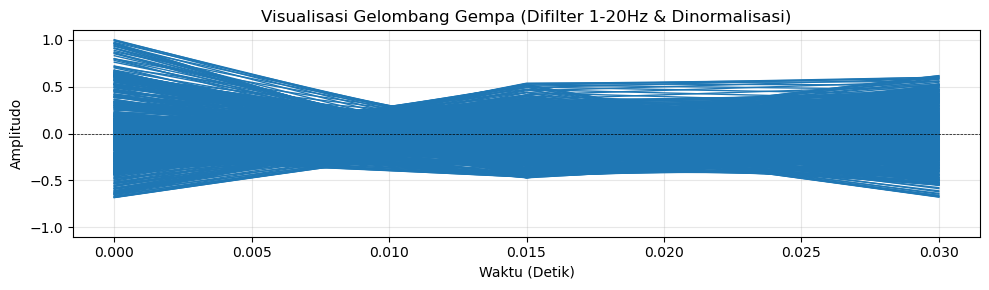


=== INFO DATA NOISE ===
Lokasi File : /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_noise_3C_npy/2009/usp000gv9n/NOISE_3C_II_KAPI_usp000gv9n.npy
Dimensi   : (3, 700) (Ekspektasi: (700,))
Tipe Data : float32 (Ekspektasi: float32)
Nilai Max : 0.6625 (Ekspektasi: ~ 1.0)
Nilai Min : -1.0000 (Ekspektasi: ~ -1.0)
Rata-rata : -0.001429 (Ekspektasi: mendekati 0)


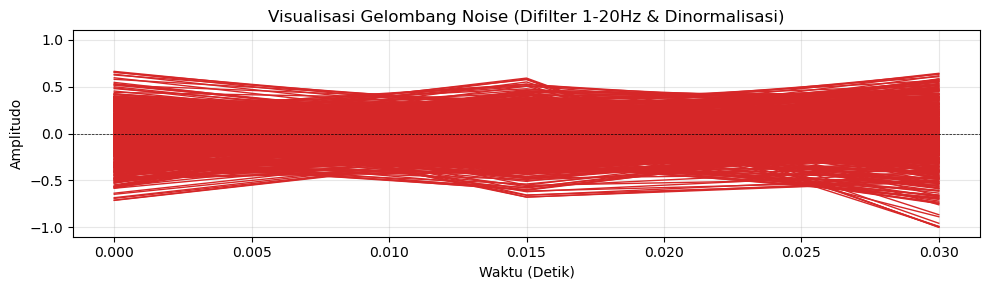

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random

def inspect_and_plot_data(folder_path, label_name, color):
    # Cek apakah folder utama ada
    if not os.path.exists(folder_path):
        print(f"❌ Folder tidak ditemukan: {folder_path}")
        return
        
    # PERBAIKAN: Menggunakan os.walk untuk mencari file .npy hingga ke dalam sub-folder
    npy_files = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith('.npy'):
                npy_files.append(os.path.join(root, file))
                
    if not npy_files:
        print(f"❌ Tidak ada file .npy di folder {label_name} atau sub-foldernya.")
        return
    
    # Ambil 1 file acak dari seluruh file yang ditemukan
    file_path = random.choice(npy_files)
    sample_file = os.path.basename(file_path)
    
    # Load data
    data = np.load(file_path)
    
    # Print Info Statistik
    print(f"\n=== INFO DATA {label_name.upper()} ===")
    print(f"Lokasi File : {file_path}")
    print(f"Dimensi   : {data.shape} (Ekspektasi: (700,))")
    print(f"Tipe Data : {data.dtype} (Ekspektasi: float32)")
    print(f"Nilai Max : {np.max(data):.4f} (Ekspektasi: ~ 1.0)")
    print(f"Nilai Min : {np.min(data):.4f} (Ekspektasi: ~ -1.0)")
    print(f"Rata-rata : {np.mean(data):.6f} (Ekspektasi: mendekati 0)")
    
    # Plotting Gelombang
    plt.figure(figsize=(10, 3))
    # Buat sumbu X berbasis waktu (700 sampel / 100 Hz = 7 detik)
    time_axis = np.linspace(0, len(data)/100, len(data))
    
    plt.plot(time_axis, data, color=color, linewidth=1)
    plt.title(f"Visualisasi Gelombang {label_name} (Difilter 1-20Hz & Dinormalisasi)")
    plt.xlabel("Waktu (Detik)")
    plt.ylabel("Amplitudo")
    plt.ylim(-1.1, 1.1)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# KONFIGURASI PATH (Sudah dilengkapi)
# ==========================================
DIR_GEMPA = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_earthquake_3C_npy"
DIR_NOISE = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_noise_3C_npy"

# Cek Data Gempa (Warna Biru)
inspect_and_plot_data(DIR_GEMPA, label_name="Gempa", color="#1f77b4")

# Cek Data Noise (Warna Merah)
inspect_and_plot_data(DIR_NOISE, label_name="Noise", color="#d62728")



In [5]:
import os
import obspy
import numpy as np
from tqdm import tqdm

def extract_pre_event_noise_3c(root_dir, output_root):
    """
    Mengekstrak 7 detik PERTAMA dari 3 komponen (Z, N, E) 
    sebagai data NOISE 3C.
    """
    total_files = sum([len(files) for r, d, files in os.walk(root_dir) if any(f.endswith('.mseed') for f in files)])
    pbar = tqdm(total=total_files, desc="Ekstraksi Pre-Event Noise 3C")

    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.endswith(".mseed"):
                mseed_path = os.path.join(root, file)
                
                # Buat hierarki folder yang sama
                relative_path = os.path.relpath(root, root_dir)
                save_dir = os.path.join(output_root, relative_path)
                os.makedirs(save_dir, exist_ok=True)
                
                try:
                    st = obspy.read(mseed_path)
                    
                    # Pastikan ketiga saluran (Z, N, E) tersedia
                    if len(st.select(component='Z')) == 0 or \
                       len(st.select(component='N')) == 0 or \
                       len(st.select(component='E')) == 0:
                        pbar.update(1)
                        continue
                        
                    tr_z = st.select(component='Z')[0]
                    tr_n = st.select(component='N')[0]
                    tr_e = st.select(component='E')[0] 
                    
                    # ==========================================
                    # 1. PRE-PROCESSING KETIGA KOMPONEN
                    # ==========================================
                    traces = [tr_z, tr_n, tr_e]
                    for tr in traces:
                        tr.detrend('demean')
                        tr.detrend('linear')
                        if tr.stats.sampling_rate != 100.0:
                            tr.resample(100.0)
                        tr.filter('bandpass', freqmin=1.0, freqmax=20.0, corners=4, zerophase=True)
                    
                    # ==========================================
                    # 2. POTONG 7 DETIK PERTAMA
                    # ==========================================
                    data_z = tr_z.data
                    data_n = tr_n.data
                    data_e = tr_e.data
                    window_size = 700 
                    
                    # Pastikan ketiga array punya minimal 700 poin
                    if min(len(data_z), len(data_n), len(data_e)) >= window_size:
                        win_z = data_z[:window_size]
                        win_n = data_n[:window_size]
                        win_e = data_e[:window_size]
                        
                        # Gabungkan ke dalam 1 matriks (3, 700)
                        window_3c = np.array([win_z, win_n, win_e])
                        
                        # Normalisasi Global (Max-Absolute dari seluruh elemen matriks)
                        max_val = np.max(np.abs(window_3c))
                        if max_val > 0:
                            window_3c = window_3c / max_val
                            
                        window_3c = window_3c.astype(np.float32)
                            
                        # Simpan dengan prefix NOISE_3C_
                        file_name = f"NOISE_3C_{os.path.splitext(file)[0]}.npy"
                        np.save(os.path.join(save_dir, file_name), window_3c)
                        
                except Exception as e:
                    pass
                
                pbar.update(1)
                
    pbar.close()

# ==========================================
# KONFIGURASI PATH
# ==========================================
ROOT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready"
OUTPUT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_noise_3C_npy"

print("🚀 Mengekstrak NOISE 3C dari seluruh sub-folder...")
extract_pre_event_noise_3c(ROOT_DIR, OUTPUT_DIR)
print("✅ Selesai! Data NOISE 3C siap disandingkan dengan Gempa 3C.")

🚀 Mengekstrak NOISE 3C dari seluruh sub-folder...


Ekstraksi Pre-Event Noise 3C: 100%|██████████| 24183/24183 [02:59<00:00, 134.57it/s]

✅ Selesai! Data NOISE 3C siap disandingkan dengan Gempa 3C.


Memuat model 3C dan 3 file JSON spasial (Z, N, E)...
Memuat model 3C dan 3 file JSON spasial (Z, N, E)...


Memuat model 3C dan 3 file JSON spasial (Z, N, E)...
Memuat model 3C dan 3 file JSON spasial (Z, N, E)...
Memuat model 3C dan 3 file JSON spasial (Z, N, E)...


No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
Memproses 14089 sampel untuk NOISE 3C...
Memproses 14089 sampel untuk NOISE 3C...
Memproses 14089 sampel untuk NOISE 3C...
Memproses 14089 sampel untuk NOISE 3C...
Memproses 14089 sampel untuk NOISE 3C...
NOISE 3C: 100%|██████████| 14089/14089 [02:08<00:00, 109.56it/s]
Memproses 13837 sampel untuk GEMPA 3C...
Memproses 13837 sampel untuk GEMPA 3C...
Memproses 13837 sampel untuk GEMPA 3C...
Memproses 13837 sampel untuk GEMPA 3C...
Memproses 13837 sampel untuk GEMPA 3C...
GEMPA 3C: 100%|██████████

Accuracy: [0.8768237263812485, 0.8768237263812485]
Accuracy (avg.): 0.8768237263812485
True positive rate: [0.5477132805628848, 0.9997536136662286]
True positive rate (avg.): 0.8768237263812485
True negative rate: [0.9997536136662286, 0.5477132805628848]
True negative rate (avg.): 0.6706431678478649
Positive predictive value: [0.9987971130713713, 0.8554462403373155]
Positive predictive value (avg.): 0.894429723307567
Negative predictive value: [0.8554462403373155, 0.9987971130713713]
Negative predictive value (avg.): 0.9598136301011198
False positive rate: [0.00024638633377135346, 0.45228671943711524]
False positive rate (avg.): 0.3293568321521351
False negative rate: [0.45228671943711524, 0.00024638633377135346]
False negative rate (avg.): 0.1231762736187515
False discovery rate: [0.0012028869286287089, 0.14455375966268447]
False discovery rate (avg.): 0.10557027669243299
F1-score: [0.7074694689008804, 0.9219874270999016]
F1-score (avg.): 0.8636504458819424

        HASIL EVALUASI FIN

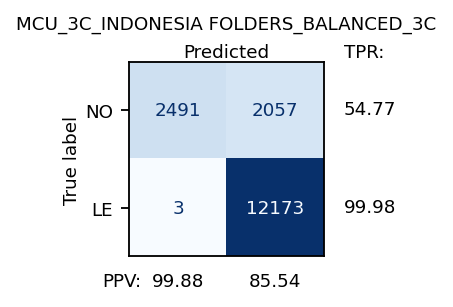

In [6]:
# -*- coding: utf-8 -*-
import sys
import os
import traceback

# 🔥 KOREKSI 1: Wajib diletakkan paling atas sebelum import TensorFlow
os.environ['TF_USE_LEGACY_KERAS'] = '1'

# 1. DAFTARKAN PATH FOLDER INDUK
MCU_QUAKE_DIR = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
if MCU_QUAKE_DIR not in sys.path:
    sys.path.append(MCU_QUAKE_DIR)

from Library import utils, dataset
import config 
import logging
from datetime import datetime
import numpy as np
from tensorflow import keras
from tqdm import tqdm

if __name__ == "__main__":
    #===================================================================
    # 1. KONFIGURASI KELAS & PATH
    #===================================================================
    true_labels = ["NO", "LE"]
    
    DIR_NOISE = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_noise_3C_npy"
    DIR_GEMPA = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_earthquake_3C_npy"
    
    model_path = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
    embedding_3C_dir = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909"
    
    MODEL_TAG = "MCU_3C_INDONESIA"
    DATA_TAG = "FOLDERS_BALANCED_3C"

    #===================================================================
    # 2. INISIALISASI LOGGER & LOAD MODEL + 3 JSON
    #===================================================================
    save_dir = os.path.join(f"{config.OUTPUT_PATH} benchmark metrics", f"{MODEL_TAG}_{DATA_TAG}_{datetime.now().strftime('%d%H%M%S')}")
    os.makedirs(save_dir, exist_ok=True)
    logging.basicConfig(filename=os.path.join(save_dir, "task_log.txt"), level=logging.INFO, filemode='w')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    logger.info("Memuat model 3C dan 3 file JSON spasial (Z, N, E)...")
    try:
        embedding_model = keras.models.load_model(filepath=model_path)
        
        # Memuat ketiga file JSON 
        emb_Z = dataset.load_embedding_data(embedding_3C_dir, "Embedding data, Z.json")
        emb_N = dataset.load_embedding_data(embedding_3C_dir, "Embedding data, N.json")
        emb_E = dataset.load_embedding_data(embedding_3C_dir, "Embedding data, E.json")
        
        # 🔥 KOREKSI 2: Gunakan fungsi 3D PDF bawaan yang sudah terbukti valid
        embeddings_PDFs_3C = utils.embedding_PDFs_3D(emb_Z, emb_N, emb_E)
        
    except Exception as e:
        logger.error(f"❌ Gagal memuat JSON/Model: {e}")
        traceback.print_exc()
        sys.exit(1)

    #===================================================================
    # 3. INFERENSI REKURSIF 3C
    #===================================================================
    total_true, total_pred = [], []

    def process_directory(directory_path, true_label, desc):
        file_list = []
        for root, dirs, files in os.walk(directory_path):
            for f in files:
                if f.endswith('.npy'):
                    file_list.append(os.path.join(root, f))
                    
        logger.info(f"Memproses {len(file_list)} sampel untuk {desc}...")
        
        for file_path in tqdm(file_list, desc=desc):
            try:
                data_3c = np.load(file_path)
                
                if data_3c.shape == (3, 700):
                    
                    # 🔥 KOREKSI 3: Normalisasi Max-Absolute per komponen secara independen
                    for c in range(3):
                        max_val = np.max(np.abs(data_3c[c]))
                        if max_val > 0:
                            data_3c[c] = data_3c[c] / max_val
                            
                    # Siapkan array 2D untuk masing-masing komponen
                    z_proc = data_3c[0].astype(np.float32).reshape(1, -1)
                    n_proc = data_3c[1].astype(np.float32).reshape(1, -1)
                    e_proc = data_3c[2].astype(np.float32).reshape(1, -1)
                    
                    # Ekstraksi fitur laten untuk masing-masing komponen
                    latent_z = utils.latent_codes_1D(z_proc, embedding_model)
                    latent_n = utils.latent_codes_1D(n_proc, embedding_model)
                    latent_e = utils.latent_codes_1D(e_proc, embedding_model)
                    
                    # Gabungkan menjadi format input 3C yang benar: [1, (latent_z, latent_n, latent_e)]
                    _input_3C = np.array([latent_z, latent_n, latent_e]).reshape(1, -1)
                    
                    # Inferensi menggunakan PDF 3 Dimensi
                    _sources_code, _, _ = utils.infer_3C_PDFs(_input_3C, embeddings_PDFs_3C, choose_pdf="Kernel")
                    
                    if _sources_code < 2:
                        total_true.append(true_label)
                        total_pred.append(_sources_code)
            
            except Exception as e:
                print(f"\n❌ ERROR PADA INFERENSI FILE: {os.path.basename(file_path)}")
                print(f"Pesan Error: {e}")
                traceback.print_exc()
                raise SystemExit("Skrip dihentikan untuk debugging.")

    # Eksekusi
    process_directory(DIR_NOISE, 0, "NOISE 3C")
    process_directory(DIR_GEMPA, 1, "GEMPA 3C")

    #===================================================================
    # 4. EVALUASI DAN METRIK FINAL
    #===================================================================
    matrix, metrics = utils.calc_confusion_metrics(total_true, total_pred)
    if matrix.shape != (2, 2): matrix = matrix[:2, :2]
    
    tn, fp, fn, tp = matrix.ravel()
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0

    print(f"\n========================================")
    print(f"        HASIL EVALUASI FINAL 3C         ")
    print(f"========================================")
    print(f"Precision (PPV): {ppv:.4f}")
    print(f"Recall (TPR)   : {tpr:.4f}")
    print(f"F1-Score       : {f1:.4f}")
    print(f"========================================")
    
    logger.info(f"PPV: {ppv:.4f}, TPR: {tpr:.4f}, F1: {f1:.4f}")

    fig = utils.plot_confusion(title=f"{MODEL_TAG} {DATA_TAG}",
                               true_labels=true_labels,
                               matrix=matrix,
                               metrics=metrics,
                               fig_size=[6, 5])
    
    fig.savefig(os.path.join(save_dir, "confusion_matrix.jpg"), dpi=300)
    dataset.save_json_data(os.path.join(save_dir, "metrics.json"), metrics)

Memuat Model 1C dan Kurva PDF 3D (Z, N, E)...
Memuat Model 1C dan Kurva PDF 3D (Z, N, E)...
Memuat Model 1C dan Kurva PDF 3D (Z, N, E)...
Memuat Model 1C dan Kurva PDF 3D (Z, N, E)...
Memuat Model 1C dan Kurva PDF 3D (Z, N, E)...
Memuat Model 1C dan Kurva PDF 3D (Z, N, E)...


No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.



🚀 MEMULAI BENCHMARK 3C DATA INDONESIA...


Memproses 14089 sampel untuk NOISE 3C (Indonesia)...
Memproses 14089 sampel untuk NOISE 3C (Indonesia)...
Memproses 14089 sampel untuk NOISE 3C (Indonesia)...
Memproses 14089 sampel untuk NOISE 3C (Indonesia)...
Memproses 14089 sampel untuk NOISE 3C (Indonesia)...
Memproses 14089 sampel untuk NOISE 3C (Indonesia)...
NOISE 3C (Indonesia): 100%|██████████| 14089/14089 [02:36<00:00, 90.10it/s] 
Memproses 13837 sampel untuk GEMPA 3C (Indonesia)...
Memproses 13837 sampel untuk GEMPA 3C (Indonesia)...
Memproses 13837 sampel untuk GEMPA 3C (Indonesia)...
Memproses 13837 sampel untuk GEMPA 3C (Indonesia)...
Memproses 13837 sampel untuk GEMPA 3C (Indonesia)...
Memproses 13837 sampel untuk GEMPA 3C (Indonesia)...
GEMPA 3C (Indonesia): 100%|██████████| 13837/13837 [02:22<00:00, 97.40it/s] 
PPV: 0.9367, TPR: 0.9790, F1: 0.9574
PPV: 0.9367, TPR: 0.9790, F1: 0.9574
PPV: 0.9367, TPR: 0.9790, F1: 0.9574
PPV: 0.9367, TPR: 0.9790, F1: 0.9574
PPV: 0.9367, TPR: 0.9790, F1: 0.9574
PPV: 0.9367, TPR: 0.9790,

Accuracy: [0.9470804686743488, 0.9470804686743488]
Accuracy (avg.): 0.9470804686743488
True positive rate: [0.8977454724651965, 0.979022094599984]
True positive rate (avg.): 0.9470804686743488
True negative rate: [0.979022094599984, 0.8977454724651965]
True negative rate (avg.): 0.9296870983908319
Positive predictive value: [0.9651655629139073, 0.9366605616605617]
Positive predictive value (avg.): 0.9478629967904836
Negative predictive value: [0.9366605616605617, 0.9651655629139073]
Negative predictive value (avg.): 0.9539631277839855
False positive rate: [0.020977905400015952, 0.1022545275348035]
False positive rate (avg.): 0.07031290160916825
False negative rate: [0.1022545275348035, 0.020977905400015952]
False negative rate (avg.): 0.052919531325651206
False discovery rate: [0.03483443708609271, 0.06333943833943834]
False discovery rate (avg.): 0.05213700320951646
F1-score: [0.9302355269036829, 0.9573729573729574]
F1-score (avg.): 0.9467079761044815

 HASIL BASELINE PSEUDO-3C (DATA 

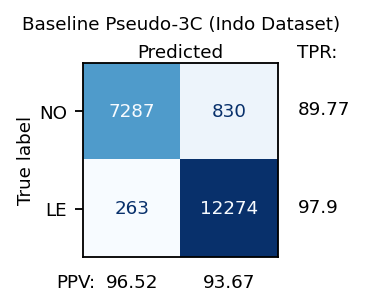

In [10]:
# -*- coding: utf-8 -*-
import sys
import os
import traceback

# 1. PAKSA KERAS LEGACY
os.environ['TF_USE_LEGACY_KERAS'] = '1'

MCU_QUAKE_DIR = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
if MCU_QUAKE_DIR not in sys.path:
    sys.path.append(MCU_QUAKE_DIR)

from Library import utils, dataset
import config 
import logging
from datetime import datetime
import numpy as np
from tensorflow import keras
from tqdm import tqdm
from scipy.signal import butter, filtfilt

if __name__ == "__main__":
    #===================================================================
    # 1. KONFIGURASI PATH DATA INDONESIA & MODEL
    #===================================================================
    true_labels = ["NO", "LE"]
    
    # Path Data 3C Indonesia
    DIR_NOISE = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_noise_3C_npy"
    DIR_GEMPA = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_earthquake_3C_npy"
    
    # Model 1C (digunakan sebagai Feature Extractor)
    model_path = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
    
    # Folder JSON Ruang Laten
    embedding_dir = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909"
    
    MODEL_TAG = "BASELINE_MCU_5-20_PSEUDO-3C"
    DATA_TAG = "INDONESIA_DATASET"

    #===================================================================
    # 2. INISIALISASI LOGGER & LOAD KOMPONEN
    #===================================================================
    save_dir = os.path.join(f"{config.OUTPUT_PATH} benchmark metrics", f"{MODEL_TAG}_{DATA_TAG}_{datetime.now().strftime('%d%H%M%S')}")
    os.makedirs(save_dir, exist_ok=True)
    logging.basicConfig(filename=os.path.join(save_dir, "task_log.txt"), level=logging.INFO, filemode='w')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    logger.info("Memuat Model 1C dan Kurva PDF 3D (Z, N, E)...")
    try:
        embedding_model = keras.models.load_model(filepath=model_path)
        
        emb_Z = dataset.load_embedding_data(embedding_dir, "Embedding data, Z.json")
        emb_N = dataset.load_embedding_data(embedding_dir, "Embedding data, N.json")
        emb_E = dataset.load_embedding_data(embedding_dir, "Embedding data, E.json")
        
        # Gabungkan menjadi PDF 3D
        embeddings_3C_PDFs = utils.embedding_PDFs_3D(emb_Z, emb_N, emb_E)
        
    except Exception as e:
        logger.error(f"❌ Gagal memuat JSON/Model: {e}")
        traceback.print_exc()
        sys.exit(1)

    #===================================================================
    # 3. FILTER BANDPASS (Sesuai Syarat Model MCU-Quake 5-20)
    #===================================================================
    def bandpass_filter_3c(data, lowcut=1.0, highcut=20.0, fs=100.0, order=4):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        
        filtered_data = np.empty_like(data)
        # Asumsi data shape: (3, 700)
        for i in range(3):
            filtered_data[i, :] = filtfilt(b, a, data[i, :])
        return filtered_data

    #===================================================================
    # 4. PROSES INFERENSI (LATE FUSION)
    #===================================================================
    total_true, total_pred = [], []

    def process_directory(directory_path, true_label, desc):
        file_list = []
        for root, dirs, files in os.walk(directory_path):
            for f in files:
                if f.endswith('.npy'):
                    file_list.append(os.path.join(root, f))
                    
        logger.info(f"Memproses {len(file_list)} sampel untuk {desc}...")
        
        for file_path in tqdm(file_list, desc=desc):
            try:
                # Dimensi ekspektasi: (3 channels, 700 timesteps)
                sample_3c = np.load(file_path)
                
                if sample_3c.shape == (3, 700):
                    
                    # 1. Bandpass Filter
                    sample_3c = bandpass_filter_3c(sample_3c, lowcut=1.0, highcut=20.0, fs=100.0)
                    
                    # 2. Normalisasi Global (mempertahankan rasio amplitudo Z, N, E)
                    max_val = np.max(np.abs(sample_3c))
                    if max_val > 0:
                        sample_3c /= max_val
                        
                    # 3. Ekstraksi Laten Independen per Channel
                    # Di .npy Anda: index 0 = Z, index 1 = N, index 2 = E
                    _in_Z = utils.latent_codes_1D(sample_3c[0].reshape(1, -1), embedding_model)
                    _in_N = utils.latent_codes_1D(sample_3c[1].reshape(1, -1), embedding_model)
                    _in_E = utils.latent_codes_1D(sample_3c[2].reshape(1, -1), embedding_model)
                    
                    # 4. Late Fusion - Susunan Wajib: [E, N, Z] sesuai utils.py
                    emb_3c = np.array([_in_E, _in_N, _in_Z]).reshape(1, -1)
                    
                    # 5. Inferensi KDE 3D
                    _sources_code, _, _ = utils.infer_3C_PDFs(emb_3c, embeddings_3C_PDFs, "Kernel")
                    
                    if _sources_code < 2:
                        total_true.append(true_label)
                        total_pred.append(_sources_code)
            except Exception:
                pass

    print("\n🚀 MEMULAI BENCHMARK 3C DATA INDONESIA...")
    process_directory(DIR_NOISE, 0, "NOISE 3C (Indonesia)")
    process_directory(DIR_GEMPA, 1, "GEMPA 3C (Indonesia)")

    #===================================================================
    # 5. EVALUASI DAN METRIK FINAL
    #===================================================================
    matrix, metrics = utils.calc_confusion_metrics(total_true, total_pred)
    if matrix.shape != (2, 2): matrix = matrix[:2, :2]
    
    tn, fp, fn, tp = matrix.ravel()
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0

    print(f"\n========================================")
    print(f" HASIL BASELINE PSEUDO-3C (DATA INDO)   ")
    print(f"========================================")
    print(f"Precision (PPV) : {ppv:.4f}")
    print(f"Recall (TPR)    : {tpr:.4f}")
    print(f"F1-Score        : {f1:.4f}")
    print(f"========================================")
    
    logger.info(f"PPV: {ppv:.4f}, TPR: {tpr:.4f}, F1: {f1:.4f}")

    fig = utils.plot_confusion(title="Baseline Pseudo-3C (Indo Dataset)",
                               true_labels=true_labels,
                               matrix=matrix,
                               metrics=metrics,
                               fig_size=[6, 5])
    
    fig.savefig(os.path.join(save_dir, "confusion_matrix_baseline_3c.jpg"), dpi=300)
    dataset.save_json_data(os.path.join(save_dir, "metrics_baseline_3c.json"), metrics)